In [24]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [8]:
insurance_data = pd.read_csv("/Users/ravihw18/ML-Algorithms/02-Lasso_Regression/insurance.csv")
X=insurance_data.drop(columns=["charges"])
y= insurance_data["charges"]
X = pd.get_dummies(X, columns= ["region"],drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
X.head()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Alpha: 0.001 Mean Squared Error: 20922599.871035974
Alpha: 0.1 Mean Squared Error: 20921803.698431384
Alpha: 1 Mean Squared Error: 20914832.635089148
Alpha: 2 Mean Squared Error: 20908106.779954527
Alpha: 5 Mean Squared Error: 20890881.00063351
Alpha: 10 Mean Squared Error: 20872844.79479669
Alpha: 20 Mean Squared Error: 20877828.53237883
Alpha: 30 Mean Squared Error: 20937537.133939773
Alpha: 40 Mean Squared Error: 21046489.293890774
Alpha: 50 Mean Squared Error: 21196929.869608898
Alpha: 100 Mean Squared Error: 22423172.68602322


<Axes: >

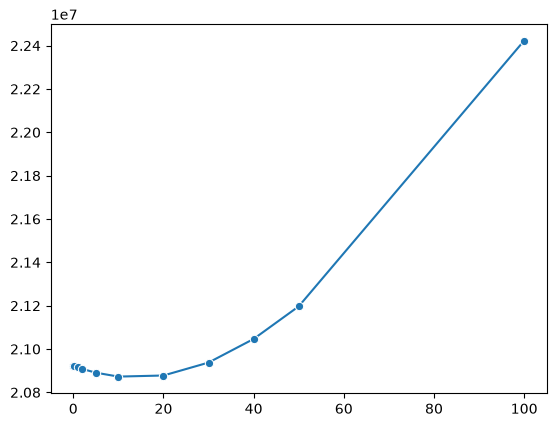

In [19]:
import seaborn as sns
alphas=[0.001, 0.1, 1, 2, 5, 10,20,30,40,50,100]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    print("Alpha:", a, "Mean Squared Error:", mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [25]:
from sklearn.linear_model import LassoCV
alphas=[0.001, 0.1, 1, 2, 5, 10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=1000,
    random_state=42
)
lasso_cv_model.fit(X_train,y_train)
print("Best alpha value:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

Best alpha value: 0.001
R2 Score: 0.8652317499151698
Mean Squared Error: 20922599.871035974
